# Mi grupo de Whatsapp

Primero importamos algunas librerias que se utilizarán y posteriormente, se abre el archivo con los chats. La carpeta data se encuentra dentro de .gitignore garantizando el anonimato de los usuarios y sus mensajes.

In [12]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import spacy
import wordcloud

nlp = spacy.load('es_core_news_md')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 7)

with open("../data/raw/chat.txt", "r", encoding="utf-8") as archivo:
    mensajes = archivo.readlines()

Se deben separar los chats en 4 columnas: fecha, hora, usuario y texto. Haremos esto mediante expresiones regulares. Los mensajes van desde el 29 de marzo del 2026 hasta el 9 de septiembre del mismo año.

In [ ]:
patron = re.compile(
    r"^\[(\d{1,2}/\d{1,2}/\d{2}), (\d{1,2}:\d{2}:\d{2} [AP]M)\] (.*?): (.*)$"
)

mensajes = []
mensaje_actual = None

with open("../data/raw/chat.txt", encoding="utf-8") as archivo:
    for linea in archivo:
        linea = linea.rstrip("\n")

        coincidencia = patron.match(linea)

        if coincidencia:
            if mensaje_actual is not None:
                mensajes.append(mensaje_actual)

            fecha, hora, usuario, texto = coincidencia.groups()

            mensaje_actual = {
                "fecha": fecha,
                "hora": hora,
                "usuario": usuario,
                "mensaje": texto
            }

        elif mensaje_actual is not None:
            mensaje_actual["mensaje"] += "\n" + linea

if mensaje_actual is not None:
    mensajes.append(mensaje_actual)

df = pd.DataFrame.from_dict(mensajes)

print(df.head())

Anonimizamos los nombres de los integrantes.

In [3]:
usuarios = df["usuario"].unique()

anonimos = {
    usuario: f"Usuario_{i:02d}"
    for i, usuario in enumerate(usuarios, start=1)
}

df["usuario"] = df["usuario"].map(anonimos)

### ¿Quién envia la mayor cantidad de mensajes?
El usuario 1 es el que envia más, con 892 mensajes; mientras que el usuario 4 es el que envia menos, con sólo 30 mensajes.

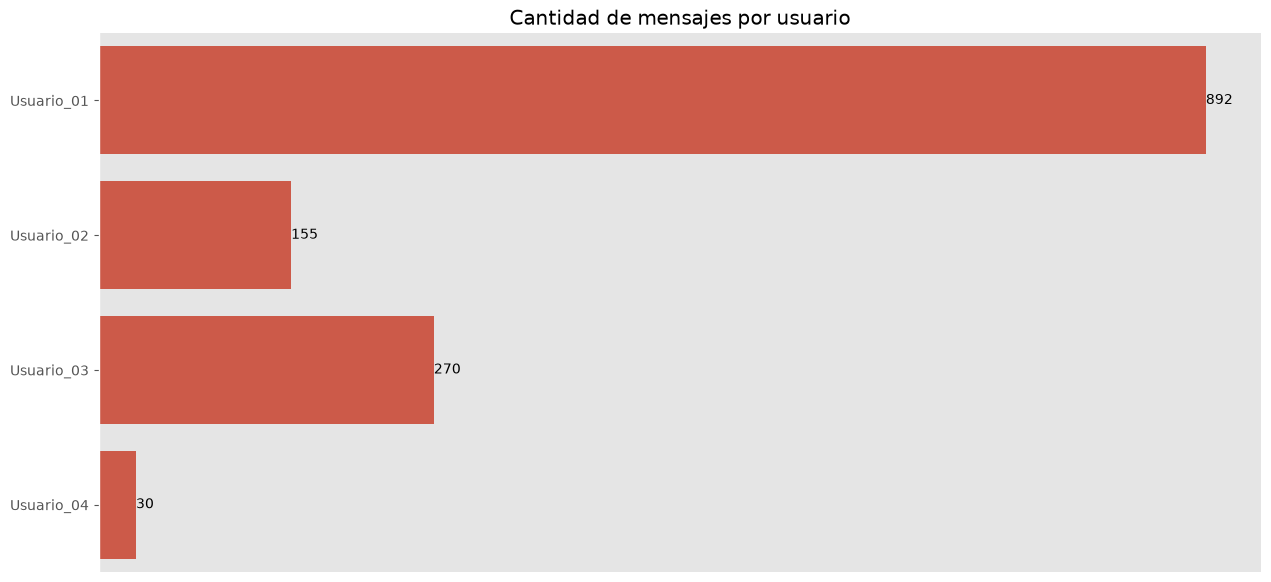

usuario
Usuario_01    892
Usuario_03    270
Usuario_02    155
Usuario_04     30
Name: count, dtype: int64

In [5]:
fig, ax1 = plt.subplots()
ax1 = sns.countplot(ax = ax1, data = df["usuario"])
ax1.bar_label(ax1.containers[0])
ax1.set_title("Cantidad de mensajes por usuario")
ax1.set(xlabel = None)
ax1.set(ylabel = None)
ax1.set(xticklabels = [])
plt.xticks([])
sns.despine(bottom = True)
plt.show()
df["usuario"].value_counts()

### ¿Cuál es el promedio de palabras por mensaje de cada usuario?
El usuario 4, a pesar de ser el que envió menos mensajes, es el que envia mensajes más largos.

In [6]:
df["numero_palabras"] = df["mensaje"].str.split().str.len()

tabla_promedios = (
    df.groupby("usuario")["numero_palabras"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

tabla_promedios.columns = ["usuario", "promedio palabras por mensaje"]

tabla_promedios

,usuario,promedio palabras por mensaje
0,Usuario_04,6.333333
1,Usuario_01,5.477578
2,Usuario_02,5.109677
3,Usuario_03,3.559259


### ¿Quién es el usuario qué más palabras ha enviado?
El usuario 1, siendo el que más mensajes envia y con un alto promedio de palabras por mensaje, es quien tiene la mayor cantidad de palabras enviadas.

In [7]:
df["numero_palabras"] = df["mensaje"].str.split().str.len()

palabras_por_usuario = (
    df.groupby("usuario")["numero_palabras"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

palabras_por_usuario.columns = ["usuario", "palabras por usuario"]

palabras_por_usuario

,usuario,palabras por usuario
0,Usuario_01,4886
1,Usuario_03,961
2,Usuario_02,792
3,Usuario_04,190


### ¿Quién es el usuario qué envía más stickers?
Otra vez, es el usuario 1 quien envia más stickers.

In [8]:
df["es_sticker"] = df["mensaje"].str.strip() == "<sticker omitido>"

stickers_por_usuario = (
    df.groupby("usuario")["es_sticker"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

stickers_por_usuario.columns = ["usuario", "stickers por usuario"]

stickers_por_usuario

,usuario,stickers por usuario
0,Usuario_01,38
1,Usuario_03,16
2,Usuario_02,3
3,Usuario_04,0


### ¿Que días de la semana se mandan más mensajes?
Se envían más mensajes los jueves y se envían menos los sabados. 

dia_semana
Lunes        163
Martes       211
Miércoles    179
Jueves       307
Viernes      182
Sábado       122
Domingo      183
Name: count, dtype: int64


<Axes: title={'center': 'Mensajes enviados por día de la semana'}, xlabel='Día de la semana', ylabel='Cantidad de mensajes'>

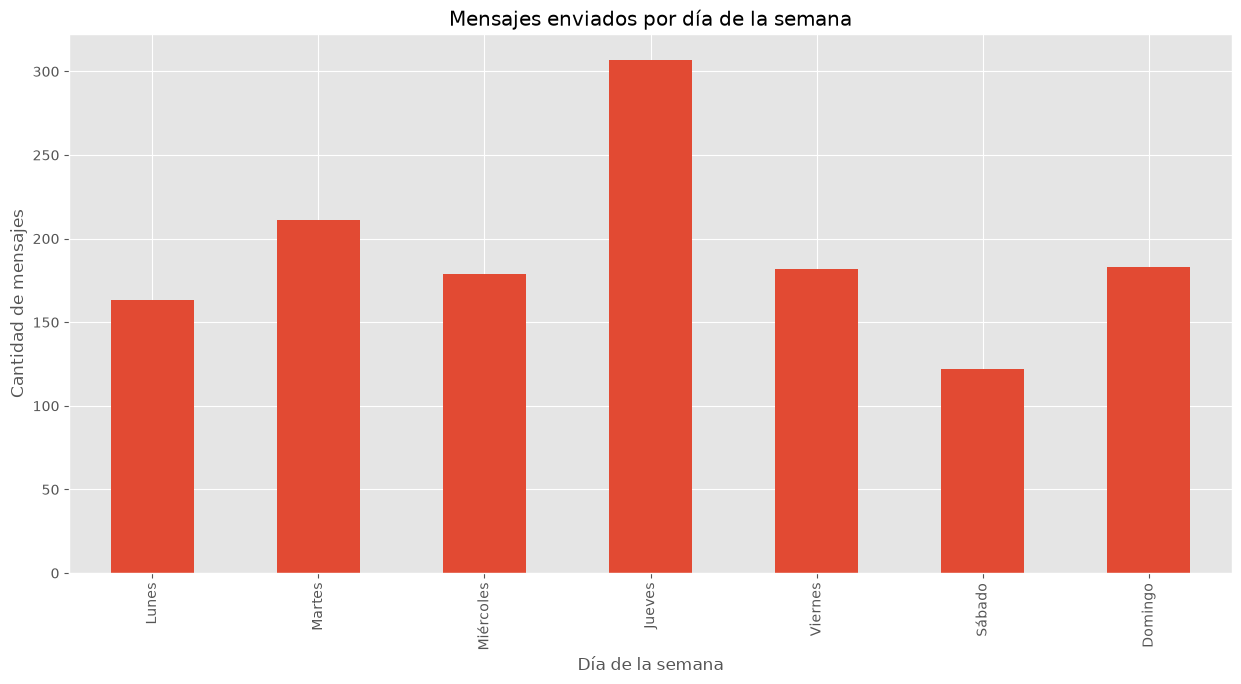

In [20]:
df["datetime"] = pd.to_datetime(
    df["fecha"] + " " + df["hora"],
    format="%m/%d/%y %I:%M:%S %p"
)

dias_es = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

df["dia_semana"] = df["datetime"].dt.day_name().map(dias_es)

orden_dias = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

mensajes_por_dia = df["dia_semana"].value_counts().reindex(orden_dias)
print(mensajes_por_dia)

mensajes_por_dia.plot(
    x="día",
    y="mensajes",
    kind="bar",
    legend=False,
    title="Mensajes enviados por día de la semana",
    xlabel="Día de la semana",
    ylabel="Cantidad de mensajes"
)

### ¿A qué horas se envían más mensajes?
Se envían más mensajes a eso de las 12 del medio día y a las 4 y 6 de la tarde. No se envían mensajes entre las 1 y 4 madrugada. Parece que durante la mañana, la cantidad de mensajes va aumentando cada hora hasta llegar al medio día, momento en que la cantidad cae pero vuelve a aumentar.

hora_del_dia
0       5
5      10
6      29
7      42
8      44
9      66
10     73
11     90
12    117
13     49
14     73
15     64
16    116
17     91
18    131
19     94
20     76
21     92
22     83
23      2
Name: count, dtype: int64


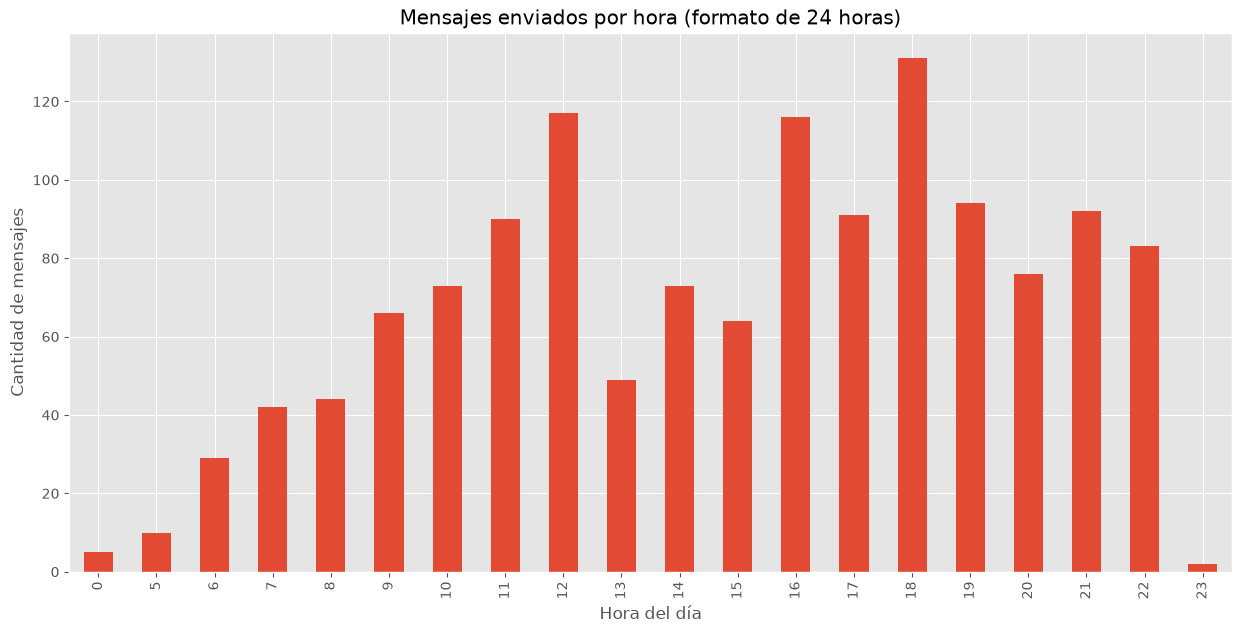

In [19]:
df["hora_del_dia"] = df["datetime"].dt.hour
mensajes_por_hora = (
    df["hora_del_dia"]
    .value_counts()
    .sort_index()
)

mensajes_por_hora.plot(
    x="hora",
    y="mensajes",
    kind="bar",
    legend=False,
    title="Mensajes enviados por hora (formato de 24 horas)",
    xlabel="Hora del día",
    ylabel="Cantidad de mensajes"
)

print(mensajes_por_hora)

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("spanish"))

### ¿Qué palabras son las más usadas por cada usuario?
Aparecen muchas palabras como "imagen", "omitida" o "reenviado" lo que significa que se envian muchas imagenes, stickers o links (estas aparecen en los mensajes como "imagen omitida", "audio omitido", "sticker omitida", etc). Si quitamos este tipo de palabras, quedan muchas palabras vacías. 

In [13]:
def obtener_palabras(texto):
    palabras = re.findall(r"\b[a-záéíóúüñ]+\b", texto.lower())
    return palabras
    
palabras_por_usuario = {}

for usuario, grupo in df.groupby("usuario"):
    palabras = []

    for mensaje in grupo["mensaje"]:
        palabras.extend(obtener_palabras(mensaje))

    palabras_por_usuario[usuario] = Counter(palabras)

for usuario, contador in palabras_por_usuario.items():
    print(f"\n{usuario}")
    print(contador.most_common(10))


Usuario_01
[('imagen', 300), ('omitida', 300), ('de', 192), ('a', 149), ('la', 145), ('https', 110), ('com', 102), ('reenviado', 102), ('y', 98), ('omitido', 92)]

Usuario_02
[('la', 30), ('que', 29), ('imagen', 24), ('omitida', 24), ('de', 22), ('a', 20), ('se', 19), ('el', 17), ('y', 12), ('en', 12)]

Usuario_03
[('de', 32), ('la', 28), ('y', 22), ('q', 22), ('que', 18), ('omitido', 18), ('a', 16), ('sticker', 16), ('el', 14), ('se', 13)]

Usuario_04
[('imagen', 11), ('omitida', 11), ('la', 9), ('que', 9), ('de', 9), ('no', 5), ('a', 5), ('ya', 4), ('en', 4), ('si', 3)]


### ¿Qué palabras son más usadas en general?
Utilizando WordCloud, vemos que nuevamente aparecen muchas imagenes, pero se aprecian muchas más palabras que con el código anterior.

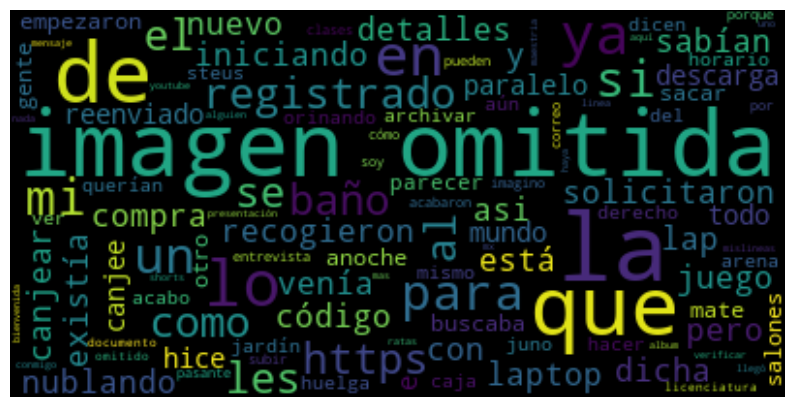

In [14]:
palabras_string = " ".join(palabras)

wc = wordcloud.WordCloud().generate(palabras_string)

plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

### Sin contar palabras vacias, ¿qué palabras son las más utilizadas?
Quitando imágenes y links (se aprecia la palabra https), parece que registrado es la palabra más compun.  

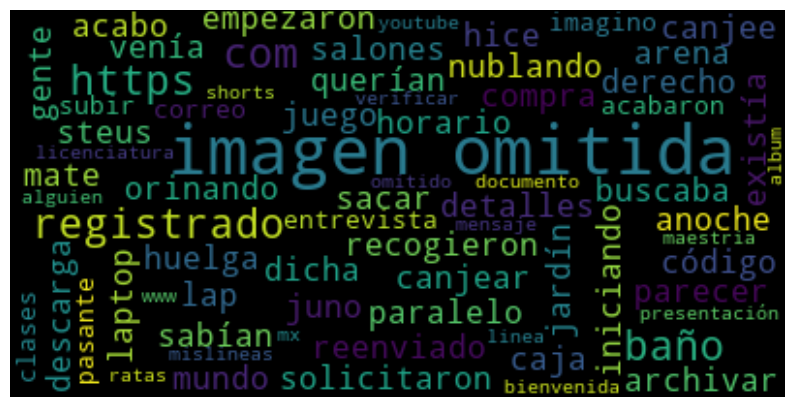

In [15]:
palabras_paro = nlp.Defaults.stop_words

palabras_string = " ".join(palabras)

wc = wordcloud.WordCloud(
    stopwords=palabras_paro
).generate(palabras_string)

plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

### ¿Cuáles son los adjetivos más utilizados en el grupo?
Todavía se observan palabras que hacen referencias a imagenes, audios o reenvíos. Si se ignoran estas palabras, se aprecian adjetivos como viejo, excelente o feliz.

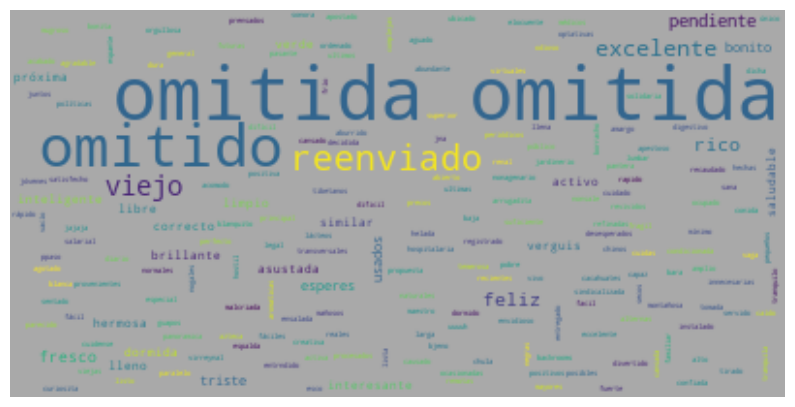

In [17]:
palabras_string = " ".join(palabras)

texto = '\n'.join(df["mensaje"].values)
doc = nlp(texto)

palabras_adjetivos = ' '.join(
    [ 
     token.norm_ for token in doc
     if token.is_alpha and not token.like_num and not token.is_stop and
        not token.is_currency and token.pos_ in ['ADJ']
    ]
)

wc = wordcloud.WordCloud(background_color="darkgray").generate(palabras_adjetivos)

plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

### ¿Cuáles son los adjetivos más utilizados por usuario?
El usuario 1 parece ser quien concentra los adjetivos más utilizados en el grupo. Se aprecian los mismos adjetivos mencionados anteriormente.

In [15]:
for usuario, grupo in df.groupby("usuario"):

    adjetivos = []

    for mensaje in grupo["mensaje"]:
        adjetivos.extend(obtener_adjetivos(mensaje))

    frecuencia = Counter(adjetivos)

    print(f"\n{usuario}")
    print(frecuencia.most_common(10))


Usuario_01
[('omitido', 392), ('[', 102), ('reenviado', 79), ('video', 24), ('>', 20), ('viejo', 11), ('buen', 9), ('nogal', 7), ('feliz', 6), ('mayor', 6)]

Usuario_02
[('omitido', 28), ('\u200d', 7), ('😂', 6), ('[', 5), ('reenviado', 5), ('>', 3), ('buen', 3), ('excelente', 3), ('manu', 2), ('feliz', 2)]

Usuario_03
[('omitido', 22), ('excelente', 6), ('rico', 4), ('bueno', 4), ('cuidense', 3), ('ahorito', 3), ('bonito', 3), ('hermoso', 3), ('okas', 2), ('mejor', 2)]

Usuario_04
[('omitido', 12), ('>', 3), ('dicho', 1), ('nuevo', 1), ('paralelo', 1), ('[', 1), ('reenviado', 1), ('imagino', 1), ('line', 1), ('registrado', 1)]
